

### Rappel du modèle

$$p_{t+1} = p_t + \kappa(v_t - p_t) + \sum_k \beta_k \tanh(\gamma m_{k,t}) + \epsilon_{t+1}$$

$$m_{k,t+1} = (1 - \alpha_k)\, m_{k,t} + \alpha_k\,(p_t - p_{t-1})$$

$$v_{t+1} = v_t + g + \eta_{t+1}$$

- $\alpha_k$ : vitesse de mémorisation (grand $\alpha$ = mémoire courte = trader rapide)
- $\beta_k$ : impact du groupe $k$ sur le prix (lié à son volume de trading)
- $\kappa$ : force de rappel vers le prix fondamental $v_t$

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr,pearsonr
from scipy import stats

print("Imports OK")

Imports OK


## 1. Chargement des données

In [2]:

investors = pd.read_csv('TEF_Investors.csv', parse_dates=['date'])
prices    = pd.read_csv('TEF_Prices.csv',   parse_dates=['date'])

investors = investors.sort_values(['investor_id', 'date']).reset_index(drop=True)
prices    = prices.sort_values('date').reset_index(drop=True)

print(f"Nombre de traders : {investors['investor_id'].nunique()}")
print(f"Nombre de jours   : {len(prices)}")
print(f"Période : {prices['date'].min().date()} → {prices['date'].max().date()}")
print()
print(investors.head(3))
print()
print(prices.head(3))

Nombre de traders : 458
Nombre de jours   : 1966
Période : 2000-01-03 → 2007-10-16

   investor_id       date  position
0          551 2000-01-03       0.0
1          551 2000-01-04       0.0
2          551 2000-01-05       0.0

   id_price       date  close   open    max    min    volume
0         1 2000-01-03  22.01  22.76  23.05  21.83  15119907
1         2 2000-01-04  21.10  21.79  22.07  20.73  16803514
2         3 2000-01-05  20.11  20.26  20.67  19.97  18517059


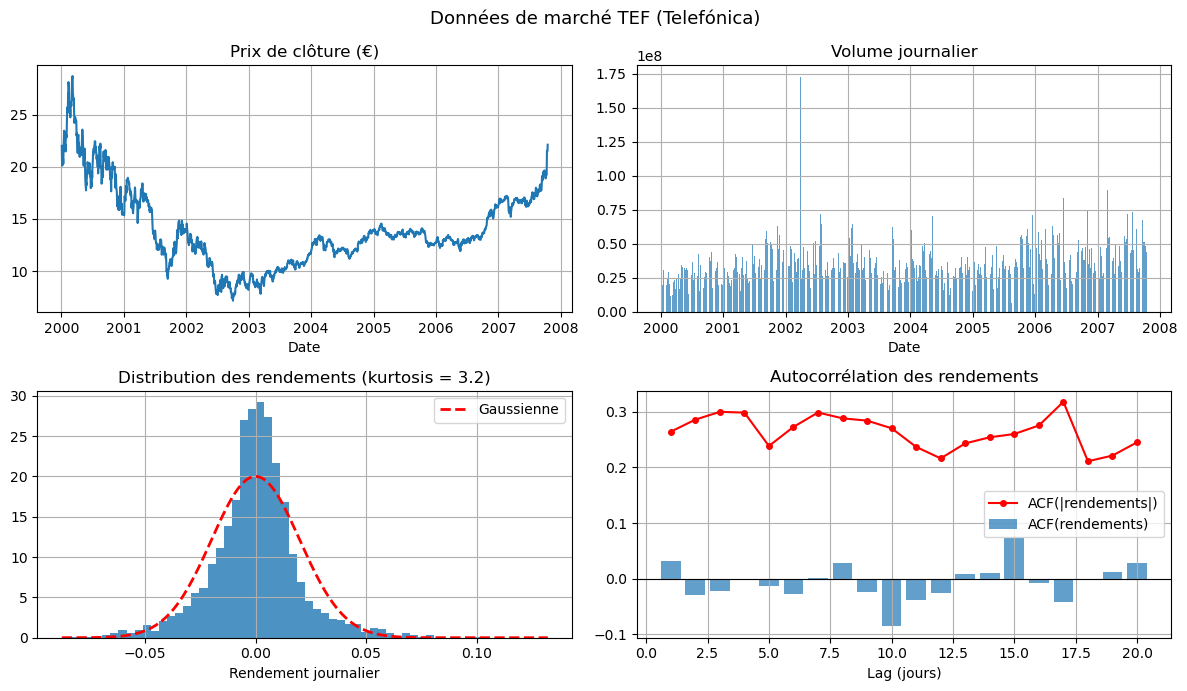

In [3]:
# Rendements log
prices['ret'] = np.log(prices['close']).diff()
ret = prices['ret'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Données de marché TEF (Telefónica)', fontsize=13)

# Prix de clôture
axes[0, 0].plot(prices['date'], prices['close'])
axes[0, 0].set_title('Prix de clôture (€)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].grid(True)

# Volume
axes[0, 1].bar(prices['date'], prices['volume'], width=1, alpha=0.7)
axes[0, 1].set_title('Volume journalier')
axes[0, 1].set_xlabel('Date')
axes[0, 1].grid(True)

# Distribution des rendements
axes[1, 0].hist(ret, bins=60, density=True, alpha=0.8)
# Comparaison avec une gaussienne
x = np.linspace(ret.min(), ret.max(), 200)
gaussienne = np.exp(-0.5 * ((x - ret.mean()) / ret.std())**2) / (ret.std() * np.sqrt(2*np.pi))
axes[1, 0].plot(x, gaussienne, 'r--', linewidth=2, label='Gaussienne')
axes[1, 0].set_title(f'Distribution des rendements (kurtosis = {ret.kurt():.1f})')
axes[1, 0].set_xlabel('Rendement journalier')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Autocorrélation des rendements et de leur valeur absolue
lags = range(1, 21)
acf_ret = [ret.autocorr(lag=k) for k in lags]
acf_abs = [ret.abs().autocorr(lag=k) for k in lags]
axes[1, 1].bar(lags, acf_ret, alpha=0.7, label='ACF(rendements)')
axes[1, 1].plot(lags, acf_abs, 'r-o', markersize=4, label='ACF(|rendements|)')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Autocorrélation des rendements')
axes[1, 1].set_xlabel('Lag (jours)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 3. Statistiques par trader

On considère qu'un trader a **tradé** un jour donné si sa position a changé par rapport à la veille.

In [4]:
# Changement de position jour par jour
investors['delta_pos'] = investors.groupby('investor_id')['position'].diff()
investors['a_trade']   = investors['delta_pos'] != 0  # True si le trader a agi ce jour-là

# Résumé par trader
trader_stats = investors.groupby('investor_id').agg(
    n_jours   = ('date', 'count'),
    n_trades  = ('a_trade', 'sum'),
    volume    = ('delta_pos', lambda x: x.abs().sum()),
).reset_index()

# Fréquence de trading = proportion de jours où le trader a agi
trader_stats['frequence'] = trader_stats['n_trades'] / trader_stats['n_jours']

print(trader_stats.describe().round(2))

       investor_id  n_jours  n_trades       volume  frequence
count       458.00    458.0    458.00       458.00     458.00
mean      11174.39   1966.0     76.69    301337.03       0.04
std        5475.19      0.0     87.34   1111004.54       0.04
min         551.00   1966.0      1.00         0.00       0.00
25%        6175.25   1966.0     42.00     23671.00       0.02
50%       10865.50   1966.0     57.50     52359.50       0.03
75%       15954.50   1966.0     87.00    178772.50       0.04
max       18433.00   1966.0   1215.00  12923838.00       0.62


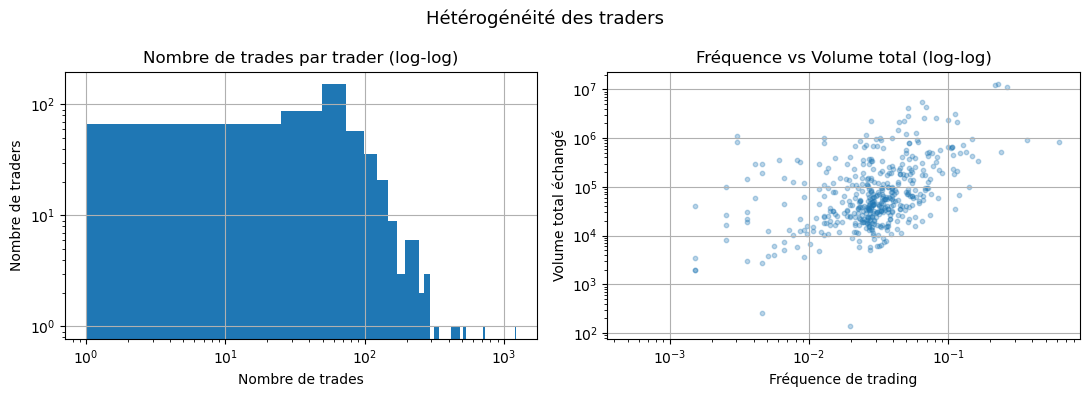

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Hétérogénéité des traders', fontsize=13)

# Distribution du nombre de trades (échelle log)
axes[0].hist(trader_stats['n_trades'][trader_stats['n_trades'] > 0],
             bins=50, log=True)
axes[0].set_xscale('log')
axes[0].set_title('Nombre de trades par trader (log-log)')
axes[0].set_xlabel('Nombre de trades')
axes[0].set_ylabel('Nombre de traders')
axes[0].grid(True)

# Fréquence vs volume
mask = trader_stats['frequence'] > 0
axes[1].scatter(trader_stats.loc[mask, 'frequence'],
                trader_stats.loc[mask, 'volume'],
                alpha=0.3, s=10)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Fréquence vs Volume total (log-log)')
axes[1].set_xlabel('Fréquence de trading')
axes[1].set_ylabel('Volume total échangé')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Estimation des échelles de temps $\alpha_k$

L'horizon d'un trader est lié à sa fréquence de trading. Si un trader trade en moyenne tous les $T$ jours, on pose :

$$\hat{\alpha} = \frac{1}{T_{\text{moyen entre trades}}}$$



On mesure les inter-trade times (ITT): le nombre de jours entre deux trades consécutifs d'un même trader.

In [6]:
# Calcul des inter-trade times (ITT) pour chaque trader
all_itt = []

for tid, group in investors[investors['a_trade']].groupby('investor_id'):
    dates = group['date'].sort_values()
    itts  = dates.diff().dt.days.dropna().values
    all_itt.extend(itts[itts > 0])

all_itt = np.array(all_itt)

# Alpha empirique de chaque trader = 1 / ITT moyen
mean_itt_by_trader = (
    investors[investors['a_trade']]
    .groupby('investor_id')['date']
    .apply(lambda d: d.sort_values().diff().dt.days.mean())
    .rename('mean_itt')
    .reset_index()
)

trader_stats = trader_stats.merge(mean_itt_by_trader, on='investor_id', how='left')
trader_stats['alpha_emp'] = 1.0 / trader_stats['mean_itt'].clip(lower=1)

print(f"Nombre d'ITT calculés : {len(all_itt)}")
print(f"ITT médian : {np.median(all_itt):.1f} jours")
print(f"ITT moyen  : {np.mean(all_itt):.1f} jours")

Nombre d'ITT calculés : 34668
ITT médian : 4.0 jours
ITT moyen  : 25.9 jours


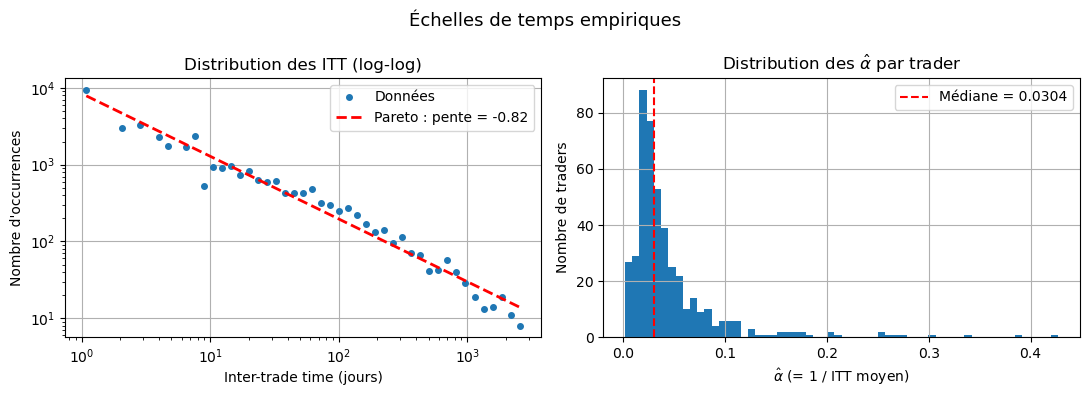

Exposant de Pareto estimé : γ = 0.82
R² de la régression log-log : 0.967


In [7]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Échelles de temps empiriques', fontsize=13)

# Distribution des ITT en log-log
bins = np.logspace(0, np.log10(all_itt.max()), 50)
counts, edges = np.histogram(all_itt, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
mask = counts > 0

axes[0].loglog(centers[mask], counts[mask], 'o', markersize=4, label='Données')

# --- Fit loi de Pareto ---
# En log-log, une loi de puissance P(x) ~ x^(-gamma) devient une droite
# On fait donc une régression linéaire sur log(centers) vs log(counts)
log_x = np.log(centers[mask])
log_y = np.log(counts[mask])
pente, intercept, r, p, _ = stats.linregress(log_x, log_y)

x_fit = np.logspace(np.log10(centers[mask].min()), np.log10(centers[mask].max()), 100)
y_fit = np.exp(intercept) * x_fit ** pente

axes[0].loglog(x_fit, y_fit, 'r--', linewidth=2,
               label=f'Pareto : pente = {pente:.2f}')
# --------------------------

axes[0].set_title('Distribution des ITT (log-log)')
axes[0].set_xlabel('Inter-trade time (jours)')
axes[0].set_ylabel('Nombre d\'occurrences')
axes[0].legend()
axes[0].grid(True)

# Distribution des alpha empiriques
alpha_vals = trader_stats['alpha_emp'].dropna()
axes[1].hist(alpha_vals, bins=60)
axes[1].axvline(alpha_vals.median(), color='red', linestyle='--',
                label=f'Médiane = {alpha_vals.median():.4f}')
axes[1].set_title('Distribution des $\\hat{\\alpha}$ par trader')
axes[1].set_xlabel('$\\hat{\\alpha}$ (= 1 / ITT moyen)')
axes[1].set_ylabel('Nombre de traders')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Exposant de Pareto estimé : γ = {-pente:.2f}")
print(f"R² de la régression log-log : {r**2:.3f}")

## 5. Classification Trend-Following vs Mean-Reverting

**Méthode :** Pour chaque trader et chaque échelle $\alpha_k$ (grille fixée), on calcule un signal mémoriel :

$$m_{k,t} = \sum_{\tau=0}^{\infty} (1-\alpha_k)^\tau \cdot r_{t-\tau}$$

C'est une moyenne exponentielle pondérée des rendements passés. Puis on corrèle ce signal avec l'**action du trader** ($\Delta\text{position}$) :

$$\rho_k = \text{corr}\bigl(\Delta\text{pos}_t,\; m_{k,t-1}\bigr)$$

- Si $\rho_k > 0$ : le trader suit la tendance → **Trend-Following**
- Si $\rho_k < 0$ : le trader va à contre-tendance → **Mean-Reverting**

In [8]:
# On prend 8 quantiles régulièrement espacés de la distribution des alpha empiriques
quantiles = np.linspace(0.05, 0.95, 8)  # évite les extrêmes 0 et 1

print(max(trader_stats['alpha_emp']))
alpha_vals = trader_stats['alpha_emp'].dropna()
ALPHA_GRID = np.quantile(alpha_vals, quantiles)

print("Grille :", np.round(ALPHA_GRID, 4))
print("Horizons (jours) :", (1 / ALPHA_GRID).astype(int))

0.4271639690358902
Grille : [0.0075 0.0183 0.0223 0.0271 0.0339 0.0442 0.0658 0.1364]
Horizons (jours) : [132  54  44  36  29  22  15   7]


In [9]:
# Grille d'échelles de temps à tester

print("Grille alpha :", ALPHA_GRID)
print("Horizon associé (jours) :", (1 / ALPHA_GRID).astype(int))

# Calcul du signal mémoriel pour chaque alpha sur la série des rendements
ret_series = prices.set_index('date')['ret'].fillna(0)

def signal_memoriel(rendements, alpha, nb_lags=200):
    """Moyenne exponentielle pondérée des rendements passés."""
    poids = (1 - alpha) ** np.arange(nb_lags)
    poids = poids / poids.sum()  # normalisation
    return np.convolve(rendements.values, poids, mode='full')[:len(rendements)]

# On stocke les signaux dans un DataFrame (une colonne par alpha)
signal_df = pd.DataFrame(index=ret_series.index)
for alpha in ALPHA_GRID:
    signal_df[alpha] = signal_memoriel(ret_series, alpha)

print("\nSignaux calculés.")
signal_df.head()

Grille alpha : [0.0075329  0.01828065 0.02228814 0.02709265 0.03387841 0.04420053
 0.0658041  0.13642758]
Horizon associé (jours) : [132  54  44  36  29  22  15   7]

Signaux calculés.


,0.007533,0.018281,0.022288,0.027093,0.033878,0.044201,0.065804,0.136428
date,,,,,,,,
2000-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2000-01-04,-0.000408,-0.000792,-0.000952,-0.001149,-0.001432,-0.001867,-0.002779,-0.005760
2000-01-05,-0.000869,-0.001678,-0.002013,-0.002425,-0.003013,-0.003908,-0.005758,-0.011531
2000-01-07,-0.000844,-0.001610,-0.001924,-0.002305,-0.002844,-0.003648,-0.005248,-0.009687
2000-01-10,-0.000549,-0.001022,-0.001209,-0.001431,-0.001736,-0.002168,-0.002940,-0.004296


In [24]:
# Classification : corrélation de Spearman entre delta_pos et signal décalé
# On ne garde que les traders avec assez de trades
traders_actifs = trader_stats.loc[trader_stats['n_trades'] >= 20, 'investor_id'].values

resultats = []
for tid in traders_actifs:
    trader = investors[investors['investor_id'] == tid].set_index('date').sort_index()
    trader['delta_pos'] = trader['position'].diff()
    trader = trader.dropna(subset=['delta_pos'])

    # Jointure avec les signaux décalés d'1 jour (signal connu avant l'action)
    merged = trader[['delta_pos']].join(signal_df.shift(1), how='inner').dropna()

    if len(merged) < 15:
       continue

    row = {'investor_id': tid}
    for alpha in ALPHA_GRID:
        #rho, _ = pearsonr(merged['delta_pos'], merged[alpha])

        rho, _ = spearmanr(merged['delta_pos'], merged[alpha])
        row[f'rho_{alpha}'] = rho
    resultats.append(row)

classif = pd.DataFrame(resultats)
print(f"Traders classifiés : {len(classif)}")

Traders classifiés : 408


['rho_0.007532903376609668', 'rho_0.018280645444952517', 'rho_0.022288139419386878', 'rho_0.027092653462104238', 'rho_0.03387841310422453', 'rho_0.04420053002677274', 'rho_0.06580410055422108', 'rho_0.13642757660167118']


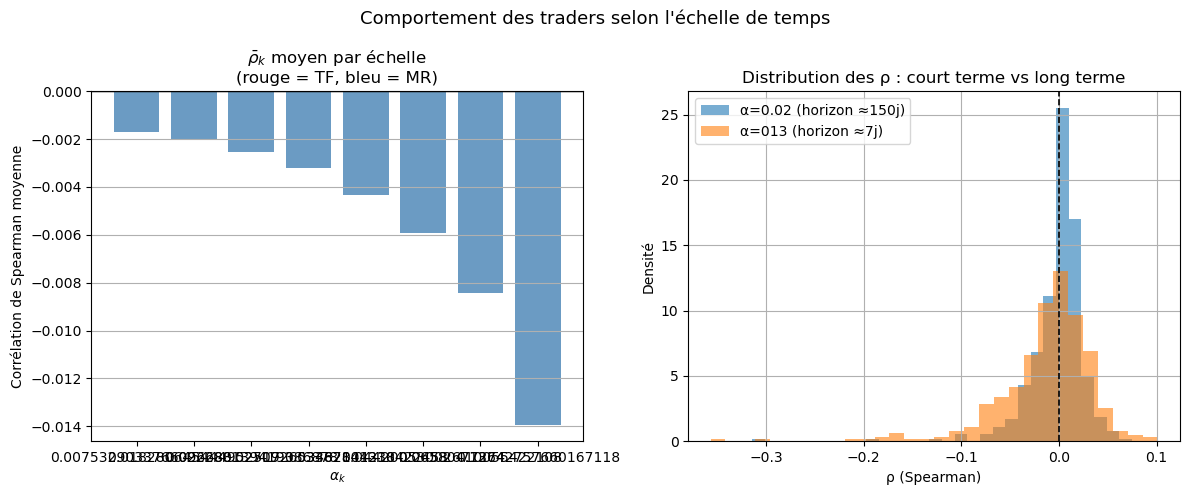

In [25]:
# Visualisation : rho moyen par échelle de temps
rho_cols   = [f'rho_{a}' for a in ALPHA_GRID]
rho_moyens = classif[rho_cols].mean().values
print(rho_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comportement des traders selon l\'échelle de temps', fontsize=13)

# Rho moyen par alpha
couleurs = ['red' if r > 0 else 'steelblue' for r in rho_moyens]
axes[0].bar([str(a) for a in ALPHA_GRID], rho_moyens, color=couleurs, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('$\\bar{\\rho}_k$ moyen par échelle\n(rouge = TF, bleu = MR)')
axes[0].set_xlabel('$\\alpha_k$')
axes[0].set_ylabel('Corrélation de Spearman moyenne')
axes[0].grid(True, axis='y')

# Distribution des rho pour une échelle courte vs longue
axes[1].hist(classif['rho_0.007532903376609668'].dropna(), bins=30, alpha=0.6,
             label=f'α=0.02 (horizon ≈150j)', density=True)
axes[1].hist(classif['rho_0.13642757660167118'].dropna(),  bins=30, alpha=0.6,
             label=f'α=013 (horizon ≈7j)',  density=True)
axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('Distribution des ρ : court terme vs long terme')
axes[1].set_xlabel('ρ (Spearman)')
axes[1].set_ylabel('Densité')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

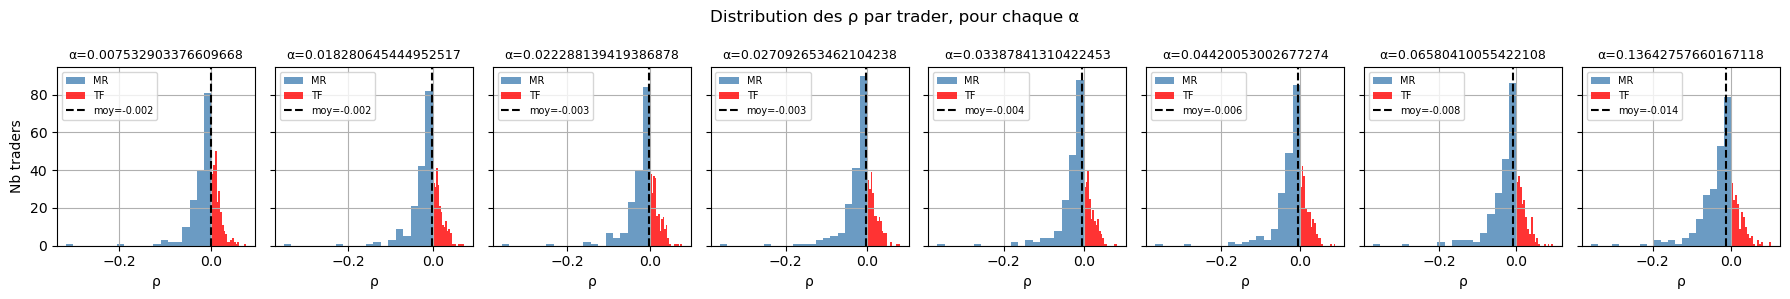

In [26]:
fig, axes = plt.subplots(1, len(ALPHA_GRID), figsize=(18, 3), sharey=True)
fig.suptitle('Distribution des ρ par trader, pour chaque α', fontsize=12)

for i, alpha in enumerate(ALPHA_GRID):
    col = f'rho_{alpha}'
    data = classif[col].dropna()
    
    axes[i].hist(data[data < 0], bins=20, color='steelblue', alpha=0.8, label='MR')
    axes[i].hist(data[data > 0], bins=20, color='red',       alpha=0.8, label='TF')
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'moy={data.mean():.3f}')
    axes[i].set_title(f'α={alpha}', fontsize=9)
    axes[i].set_xlabel('ρ')
    if i == 0:
        axes[i].set_ylabel('Nb traders')
    axes[i].legend(fontsize=7)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 6. Relation entre horizon ($\alpha_k$) et volume ($\beta_k$)

les traders qui tradent souvent ont-ils un impact plus grand sur le marché ?

On proxye $\beta_k$ par la part de volume de chaque trader dans le volume total.

In [27]:
# Fusion des stats de trading avec la classification
merged_stats = classif.merge(
    trader_stats[['investor_id', 'alpha_emp', 'volume', 'frequence', 'n_trades']],
    on='investor_id', how='left'
)

# Beta empirique = part du volume total
merged_stats['beta_emp'] = merged_stats['volume'] / merged_stats['volume'].sum()

# Echelle optimale : alpha qui maximise |rho|
def meilleur_alpha(row):
    rhos = [row[f'rho_{a}'] for a in ALPHA_GRID]
    idx  = np.nanargmax(np.abs(rhos))
    return ALPHA_GRID[idx], rhos[idx]

merged_stats[['alpha_best', 'rho_best']] = merged_stats.apply(
    lambda r: pd.Series(meilleur_alpha(r)), axis=1
)
merged_stats['comportement'] = np.where(
    merged_stats['rho_best'] > 0, 'Trend-Following', 'Mean-Reverting'
)

print(merged_stats['comportement'].value_counts())

comportement
Trend-Following    212
Mean-Reverting     196
Name: count, dtype: int64


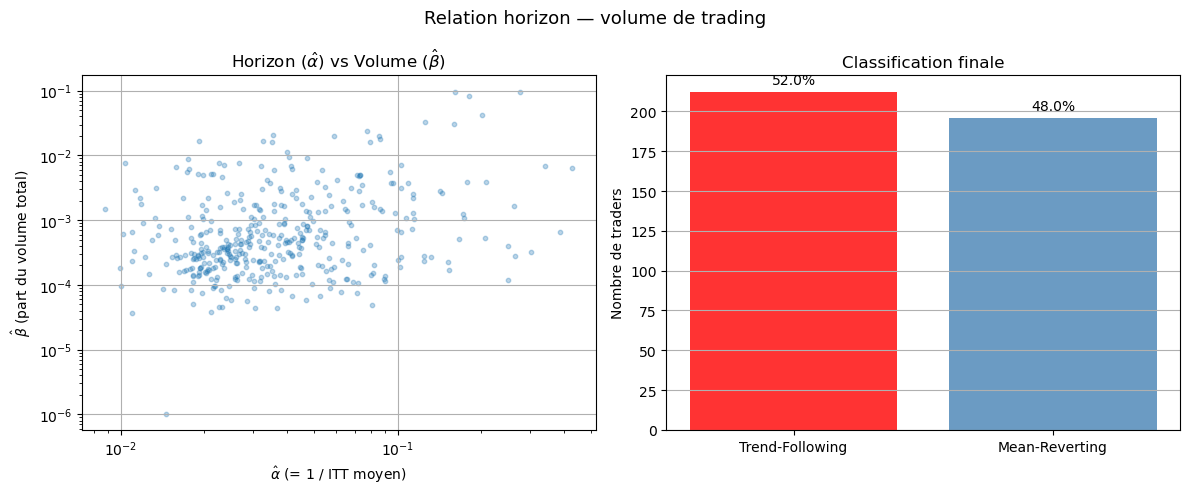

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Relation horizon — volume de trading', fontsize=13)

# Alpha vs Beta (log-log)
mask = merged_stats['alpha_emp'].notna() & merged_stats['beta_emp'].notna()
axes[0].scatter(
    merged_stats.loc[mask, 'alpha_emp'],
    merged_stats.loc[mask, 'beta_emp'],
    alpha=0.3, s=10
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Horizon ($\\hat{\\alpha}$) vs Volume ($\\hat{\\beta}$)')
axes[0].set_xlabel('$\\hat{\\alpha}$ (= 1 / ITT moyen)')
axes[0].set_ylabel('$\\hat{\\beta}$ (part du volume total)')
axes[0].grid(True)

# Répartition TF / MR
counts = merged_stats['comportement'].value_counts()
axes[1].bar(counts.index, counts.values, color=['red', 'steelblue'], alpha=0.8)
axes[1].set_title('Classification finale')
axes[1].set_ylabel('Nombre de traders')
for i, (label, val) in enumerate(counts.items()):
    axes[1].text(i, val + 5, f'{100*val/len(merged_stats):.1f}%', ha='center')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

## 7. Calibration des paramètres du modèle

On regroupe les traders par échelle temporelle optimale pour obtenir les couples $(\alpha_k, \beta_k)$ du modèle.

In [29]:
# Paramètres agrégés par groupe d'échelle
params = merged_stats.groupby('alpha_best').agg(
    n_traders = ('investor_id', 'count'),
    beta_k    = ('beta_emp', 'sum'),
    rho_moyen = ('rho_best', 'mean'),
).reset_index().rename(columns={'alpha_best': 'alpha_k'})

params['beta_k'] = params['beta_k'] / params['beta_k'].sum()  # normalisation
params['beta_k_signe'] = params['beta_k'] * np.sign(params['rho_moyen'])  # TF>0, MR<0
params['horizon_jours'] = (1 / params['alpha_k']).astype(int)

print(params[['alpha_k', 'horizon_jours', 'n_traders', 'beta_k', 'beta_k_signe', 'rho_moyen']].to_string(index=False))

 alpha_k  horizon_jours  n_traders   beta_k  beta_k_signe  rho_moyen
0.007533            132         55 0.063152      0.063152   0.004163
0.018281             54         28 0.148776      0.148776   0.010823
0.022288             44         17 0.019425      0.019425   0.013122
0.027093             36         16 0.052070      0.052070   0.010846
0.033878             29         21 0.112810      0.112810   0.010868
0.044201             22         16 0.015761      0.015761   0.013810
0.065804             15         39 0.127791     -0.127791  -0.012473
0.136428              7        216 0.460214     -0.460214  -0.024160


## 8. Simulation du modèle calibré

-0.17600998890776487


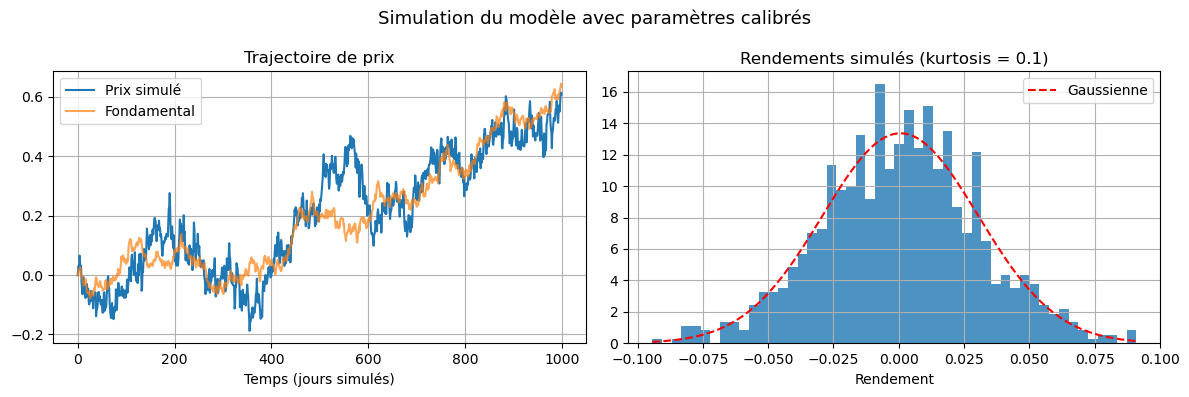

In [34]:
def simuler_modele(T, kappa, gamma, sigma_eps, alpha_k, beta_k, seed=42):
    """
    Simule le modèle de Chiarella modifié.
    Retourne la série de prix p et le prix fondamental v.
    """
    np.random.seed(seed)
    K = len(alpha_k)
    p = np.zeros(T)
    v = np.zeros(T)
    m = np.zeros((K, T))  # mémoires multi-échelles

    for t in range(1, T):
        # Mise à jour des mémoires
        if t >= 2:
            m[:, t] = (1 - alpha_k) * m[:, t-1] + alpha_k * (p[t-1] - p[t-2])

        # Signal chartiste agrégé
        signal = np.sum(beta_k * np.tanh(gamma * m[:, t]))

        # Mise à jour du prix
        p[t] = p[t-1] + kappa * (v[t-1] - p[t-1]) + signal + np.random.normal(0, sigma_eps)

        # Marche aléatoire du fondamental
        v[t] = v[t-1] + np.random.normal(0, 0.011)

    return p, v


T = 1000
alpha_cal = params['alpha_k'].values
beta_cal  = params['beta_k_signe'].values

print(sum(beta_cal))

p_cal, v_cal = simuler_modele(T, kappa=0.05, gamma=2, sigma_eps=0.03,
                               alpha_k=alpha_cal, beta_k=beta_cal)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Simulation du modèle avec paramètres calibrés', fontsize=13)

axes[0].plot(p_cal, label='Prix simulé')
axes[0].plot(v_cal, alpha=0.7, label='Fondamental')
axes[0].set_title('Trajectoire de prix')
axes[0].set_xlabel('Temps (jours simulés)')
axes[0].legend()
axes[0].grid(True)

ret_sim = np.diff(p_cal)
axes[1].hist(ret_sim, bins=50, density=True, alpha=0.8)
x = np.linspace(ret_sim.min(), ret_sim.max(), 200)
gaus = np.exp(-0.5*((x - ret_sim.mean())/ret_sim.std())**2) / (ret_sim.std()*np.sqrt(2*np.pi))
axes[1].plot(x, gaus, 'r--', label='Gaussienne')
axes[1].set_title(f'Rendements simulés (kurtosis = {pd.Series(ret_sim).kurt():.1f})')
axes[1].set_xlabel('Rendement')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [31]:

def jacobienne(kappa, gamma, alpha_k, beta_k):

    n = len(alpha_k)
    J = np.zeros((n + 1, n + 1))

    # Première ligne : dérivées de delta_p par rapport à (p, m_1, ..., m_n)
    J[0, 0] = -kappa
    for k in range(n):
        J[0, k + 1] = beta_k[k] * gamma

    # Lignes suivantes : dérivées de delta_m_k
    for k in range(n):
        J[k + 1, 0] = -alpha_k[k] * kappa          # d(m_k)/d(p)
        for j in range(n):
            if j == k:
                J[k + 1, k + 1] = alpha_k[k] * (beta_k[k] * gamma - 1)
            else:
                J[k + 1, j + 1] = alpha_k[k] * beta_k[j] * gamma

    return J

def est_stable(kappa, gamma, alpha_k, beta_k):
    J = jacobienne(kappa, gamma, alpha_k, beta_k)
    valeurs_propres = np.linalg.eigvals(J)
    parties_reelles = np.real(valeurs_propres)
    return np.all(parties_reelles < 0), valeurs_propres

# Test avec vos paramètres calibrés
stable, vp = est_stable(kappa=0.05, gamma=2.0,
                         alpha_k=alpha_cal, beta_k=beta_cal)

print(f"Système stable : {stable}")
print(f"\nValeurs propres :")
for i, v in enumerate(vp):
    signe = "✓" if np.real(v) < 0 else "✗ INSTABLE"
    print(f"  λ_{i+1} = {np.real(v):+.4f} + {np.imag(v):+.4f}i   {signe}")

Système stable : True

Valeurs propres :
  λ_1 = -0.2887 + +0.0000i   ✓
  λ_2 = -0.0720 + +0.0000i   ✓
  λ_3 = -0.0438 + +0.0000i   ✓
  λ_4 = -0.0077 + +0.0000i   ✓
  λ_5 = -0.0202 + +0.0098i   ✓
  λ_6 = -0.0202 + -0.0098i   ✓
  λ_7 = -0.0306 + +0.0000i   ✓
  λ_8 = -0.0243 + +0.0000i   ✓
  λ_9 = -0.0213 + +0.0000i   ✓


## 9. Résumé

---

### Références
- Gutierrez-Roig, M. et al. (2019). *Aggregation and emergence in agent-based financial markets.* Zenodo.
- Chiarella, C. (1992). The dynamics of speculative behaviour. *Annals of Operations Research.*
- Adam A. Majewski, Stefano Ciliberti, Jean-Philippe Bouchaud *Co-existence of trend and value in financial markets:
Estimating an extended Chiarella model* 


In [32]:
print("=" * 55)
print("RÉSUMÉ — PARAMÈTRES CALIBRÉS")
print("=" * 55)
print(f"Traders analysés        : {len(merged_stats)}")
print(f"ITT médian              : {np.median(all_itt):.1f} jours")
print()
print("Paramètres fixes :")
print(f"  kappa = 0.05  (retour vers fondamental)")
print(f"  gamma = 2.0   (non-linéarité du signal)")
print()
print("Groupes calibrés :")
print(f"{'alpha_k':>8} {'horizon':>10} {'n_traders':>10} {'beta_k':>8} {'comportement':>16}")
print("-" * 55)
for _, row in params.iterrows():
    beh = "Trend-Following" if row['rho_moyen'] > 0 else "Mean-Reverting"
    print(f"{row['alpha_k']:>8.2f} {row['horizon_jours']:>8}j {int(row['n_traders']):>10} "
          f"{row['beta_k_signe']:>+8.4f} {beh:>16}")
print()
print("Classification :")
for beh, cnt in merged_stats['comportement'].value_counts().items():
    print(f"  {beh:20s} : {cnt} traders ({100*cnt/len(merged_stats):.1f}%)")

RÉSUMÉ — PARAMÈTRES CALIBRÉS
Traders analysés        : 408
ITT médian              : 4.0 jours

Paramètres fixes :
  kappa = 0.05  (retour vers fondamental)
  gamma = 2.0   (non-linéarité du signal)

Groupes calibrés :
 alpha_k    horizon  n_traders   beta_k     comportement
-------------------------------------------------------
    0.01    132.0j         55  +0.0632  Trend-Following
    0.02     54.0j         28  +0.1488  Trend-Following
    0.02     44.0j         17  +0.0194  Trend-Following
    0.03     36.0j         16  +0.0521  Trend-Following
    0.03     29.0j         21  +0.1128  Trend-Following
    0.04     22.0j         16  +0.0158  Trend-Following
    0.07     15.0j         39  -0.1278   Mean-Reverting
    0.14      7.0j        216  -0.4602   Mean-Reverting

Classification :
  Trend-Following      : 212 traders (52.0%)
  Mean-Reverting       : 196 traders (48.0%)
